In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

import lightgbm as lgb
from lightgbm import LGBMClassifier

import shap

pd.set_option('display.max_columns', 200)
plt.rcParams['figure.dpi'] = 100

lgbm_tuned   = joblib.load("../models/lgbm_tuned.pkl")
preprocessor = joblib.load("../models/preprocessor.pkl")


df = pd.read_parquet("../data/loans_clean.parquet")

df['dti'] = df['dti'].replace([-1, 999], np.nan).clip(upper=100)
df["credit_history_months"] = df['credit_history_months'].replace(999, np.nan)
df['annual_inc'] = df["annual_inc"].clip(upper=1_000_000)
df['revol_util'] = df['revol_util'].clip(upper=100)

df_train = df[df['issue_year'].isin([2014, 2015])].copy()
df_val   = df[df["issue_year"] == 2016].copy()
df_test  = df[df['issue_year'] == 2017].copy()

y_val   = df_val['default'].values


print(f"SHAP version: {shap.__version__}")

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0


In [2]:
df_val_fe = df_val.copy()

def prep_features(df):
    df = df.copy()
    
    redundant = [
        "fico_range_high",
        "funded_amnt",
        "funded_amnt_inv",
        "num_sats",
        "installment",
        "num_rev_tl_bal_gt_0",
    ]

    joint_cols = [c for c in df.columns if c.startswith("sec_app") or c.endswith("_joint")]

    high_cardinality = ["zip_code", "sub_grade"]

    split_cols = ["issue_year"]

    emp_map = {
        "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
        "5 years": 5, "6 years": 6, '7 years': 7, "8 years": 8, "9 years": 9,
        "10+ years": 10
    }
    df["emp_length"] = df["emp_length"].map(emp_map)
    
    cols_to_drop = redundant + joint_cols + high_cardinality + split_cols
    
    df = df.drop(
        columns=[c for c in cols_to_drop if c in df.columns]
    )
    
    return df



df_val_fe = prep_features(df_val_fe)
x_val = df_val_fe.drop(columns=['default'])
x_val['term'] = x_val['term'].str.extract(r'(\d+)').astype(int)

print(f"x_val shape: {x_val.shape}")

x_val shape: (293095, 79)


In [3]:
import joblib
champion = joblib.load("../models/champion_lgbm.pkl")

preprocessor = champion['preprocessor']
base_model = champion['base_model']
calibrator = champion['calibrator']
best_threshold = champion['best_threshold']

x_val_proc = preprocessor.transform(x_val)

feature_names = preprocessor.get_feature_names_out()

print(f"Champion loaded successfully")
print(f"Preprocessed features: {x_val_proc.shape[1]}")
print(f"Best threshold: {best_threshold:.4f}")
print(f"First 5 feature names: {feature_names[:5].tolist()}")

# sanity check
val_probs_raw = base_model.predict_proba(x_val_proc)[:, 1]
val_probs_cal = calibrator.predict(val_probs_raw)

print(f"\nSanity check:")
print(f"  AUC (uncalibrated): {roc_auc_score(y_val, val_probs_raw):.4f}")
print(f"  Brier (calibrated): {brier_score_loss(y_val, val_probs_cal):.4f}")

Champion loaded successfully
Preprocessed features: 155
Best threshold: 0.1592
First 5 feature names: ['num__loan_amnt', 'num__term', 'num__int_rate', 'num__emp_length', 'num__annual_inc']


/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Sanity check:
  AUC (uncalibrated): 0.7280
  Brier (calibrated): 0.1570


In [4]:
import time

np.random.seed(42)
sample_size = 5000
sample_idx = np.random.choice(len(x_val_proc), size=sample_size, replace=False)
x_val_sample = x_val_proc[sample_idx]
y_val_sample = y_val[sample_idx]

print("Creating SHAP TreeExplainer...")
explainer = shap.TreeExplainer(base_model)

print(f"Computing SHAP values for {sample_size:,} samples...")
start = time.time()
shap_values = explainer.shap_values(x_val_sample)
elapsed = time.time() - start
print(f"Done in {elapsed:.1f}s")

if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
    print("SHAP returned list format; using positive class")
else:
    shap_values_pos = shap_values
    print("SHAP returned array format")

print(f"\nSHAP values shape: {shap_values_pos.shape}")
print(f"Expected: ({sample_size}, {x_val_sample.shape[1]})")
print(f"\nExplainer expected value (base log-odds): {explainer.expected_value}")

Creating SHAP TreeExplainer...
Computing SHAP values for 5,000 samples...
Done in 13.6s
SHAP returned array format

SHAP values shape: (5000, 155)
Expected: (5000, 155)

Explainer expected value (base log-odds): -1.677515659943213


/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


/var/folders/r_/mwc7qts15xd177svcc33_blr0000gp/T/ipykernel_40074/2587075106.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


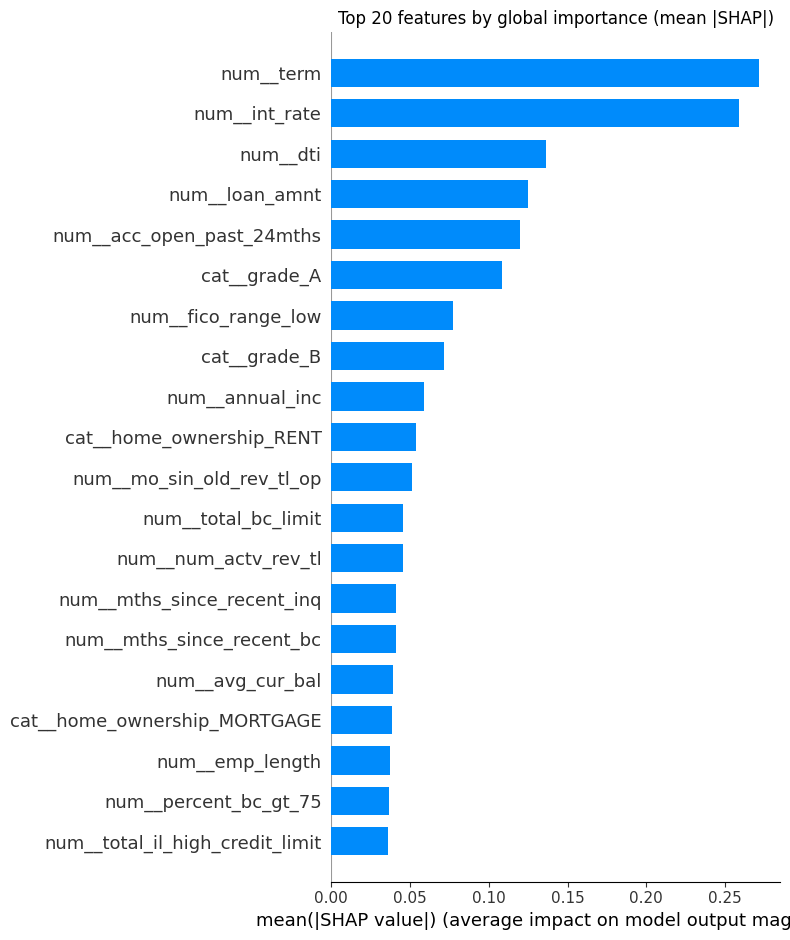

In [5]:
#bar plot: features ranked by mean absolute SHAP value
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_pos, 
    x_val_sample, 
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title("Top 20 features by global importance (mean |SHAP|)", fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/shap_global_importance.png', dpi=120, bbox_inches='tight')
plt.show()


/var/folders/r_/mwc7qts15xd177svcc33_blr0000gp/T/ipykernel_40074/1424747337.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


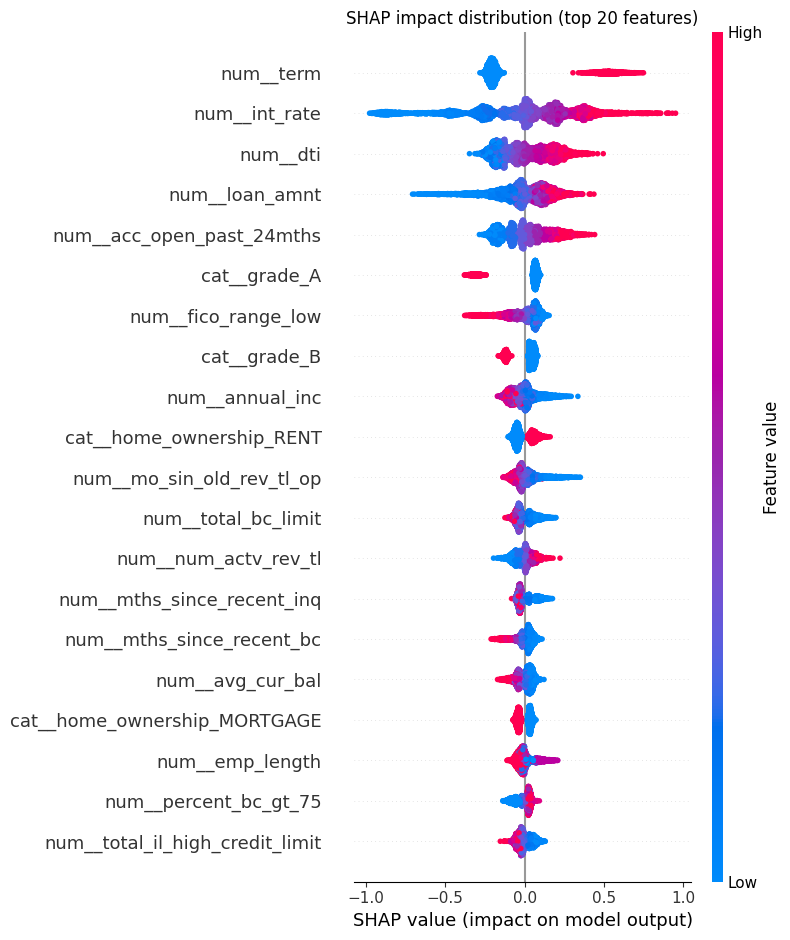

In [6]:
# Beeswarm: how each feature's values affect predictions
fig = plt.figure(figsize = (10, 10))
shap.summary_plot(
    shap_values_pos,
    x_val_sample,
    feature_names = feature_names,
    max_display = 20,
    show= False
)
plt.title("SHAP impact distribution (top 20 features)", fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

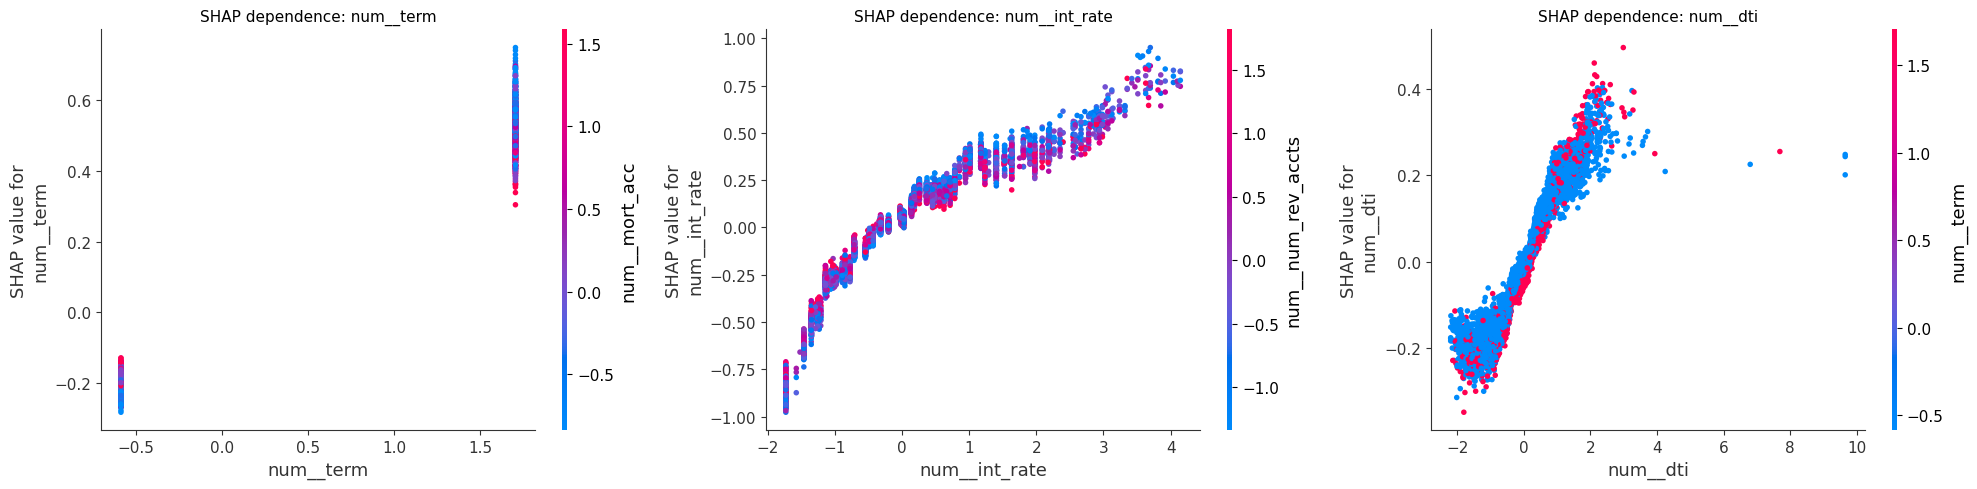

In [7]:
x_val_sample_df = pd.DataFrame(x_val_sample, columns=feature_names)

top_features = ['num__term', 'num__int_rate', 'num__dti']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, feature in zip(axes, top_features):
    feature_idx = list(feature_names).index(feature)
    shap.dependence_plot(
        feature_idx,
        shap_values_pos,
        x_val_sample_df,
        feature_names=feature_names,
        ax=ax,
        show=False,
        interaction_index='auto'
    )
    ax.set_title(f"SHAP dependence: {feature}", fontsize=11)

plt.tight_layout()
plt.savefig("../reports/figures/shap_dependence_top3.png", dpi=120, bbox_inches='tight')
plt.show()

In [8]:
val_probs_raw_all = base_model.predict_proba(x_val_proc)[:, 1]
val_probs_all     = calibrator.predict(val_probs_raw_all)

# Pick three interesting cases

high_risk_idx = int(np.argmax(val_probs_all))
low_risk_idx =int(np.argmin(val_probs_all))
borderline_idx = int(np.argmin(np.abs(val_probs_all - best_threshold)))

selected = [
    ('High-risk rejection', high_risk_idx),
    ('Low-risk approval',   low_risk_idx),
    ('Borderline case',     borderline_idx)
]


for label, idx in selected:
    row = x_val.iloc[idx]
    print(f"\n{'='*60}")
    print(f"  {label}")
    print('='*60)
    print(f"  Predicted P(default): {val_probs_all[idx]:.4f}")
    print(f"  Decision: {'APPROVE' if val_probs_all[idx] < best_threshold else 'REJECT'} (threshold {best_threshold:.4f})")
    print(f"  Actual outcome: {'DEFAULTED' if y_val[idx] else 'PAID'}")
    print(f"  ---")
    print(f"  Loan:     ${row['loan_amnt']:,.0f}, {row['term']} months, {row['int_rate']:.1f}% interest, grade {row['grade']}")
    print(f"  Borrower: ${row['annual_inc']:,.0f}/yr income, DTI {row['dti']:.1f}%, FICO {row['fico_range_low']:.0f}")
    print(f"  Profile:  {row['emp_length']} yrs employed, {row['home_ownership']}, purpose: {row['purpose']}")
    print(f"  History:  {row['acc_open_past_24mths']:.0f} accounts opened past 24mo, {row['mo_sin_old_rev_tl_op']:.0f} mo since oldest tradeline")

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  High-risk rejection
  Predicted P(default): 1.0000
  Decision: REJECT (threshold 0.1592)
  Actual outcome: DEFAULTED
  ---
  Loan:     $24,750, 60 months, 28.9% interest, grade G
  Borrower: $55,000/yr income, DTI 37.6%, FICO 670
  Profile:  10.0 yrs employed, RENT, purpose: credit_card
  History:  9 accounts opened past 24mo, 137 mo since oldest tradeline

  Low-risk approval
  Predicted P(default): 0.0000
  Decision: APPROVE (threshold 0.1592)
  Actual outcome: PAID
  ---
  Loan:     $5,000, 36 months, 5.3% interest, grade A
  Borrower: $131,000/yr income, DTI 11.3%, FICO 800
  Profile:  10.0 yrs employed, MORTGAGE, purpose: home_improvement
  History:  5 accounts opened past 24mo, 190 mo since oldest tradeline

  Borderline case
  Predicted P(default): 0.1579
  Decision: APPROVE (threshold 0.1592)
  Actual outcome: PAID
  ---
  Loan:     $2,150, 36 months, 17.0% interest, grade D
  Borrower: $47,500/yr income, DTI 22.0%, FICO 690
  Profile:  3.0 yrs employed, MORTGAGE, purpose: o

/Users/nachimorales/Documents/projects/loan-default-fairness/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


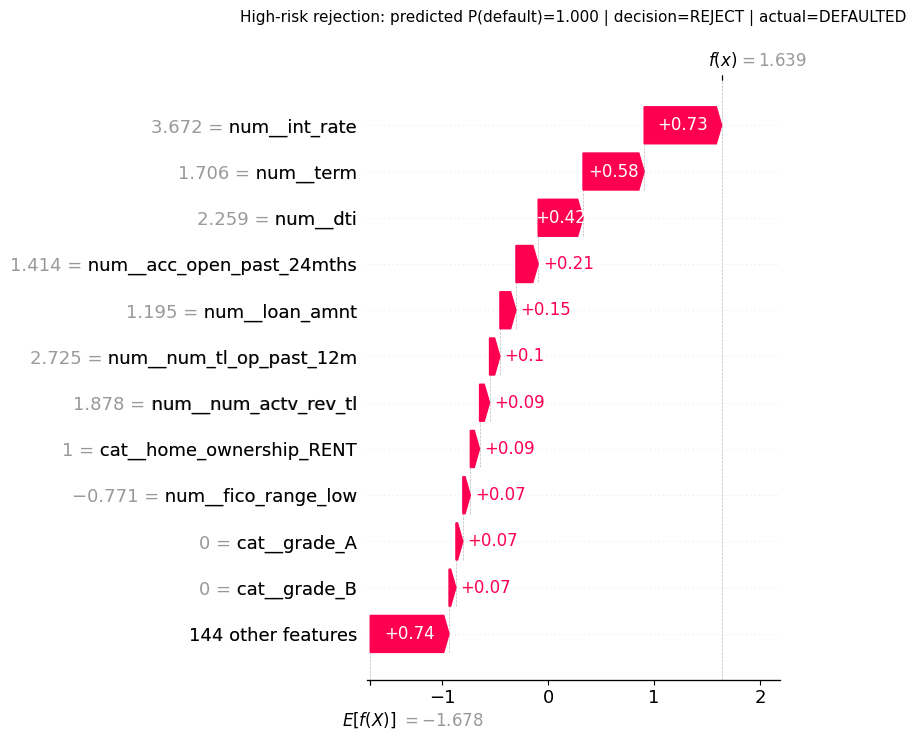

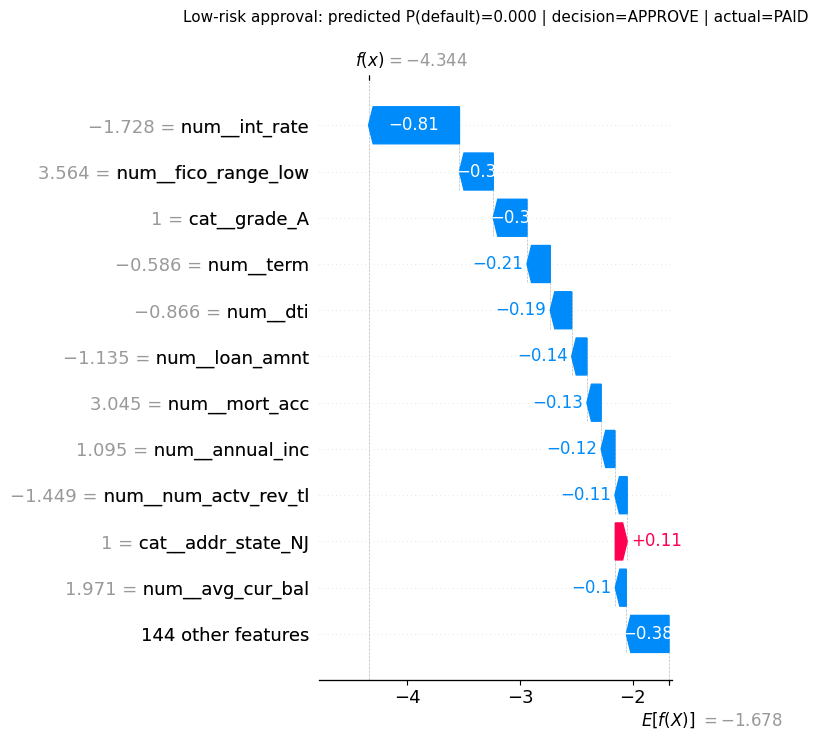

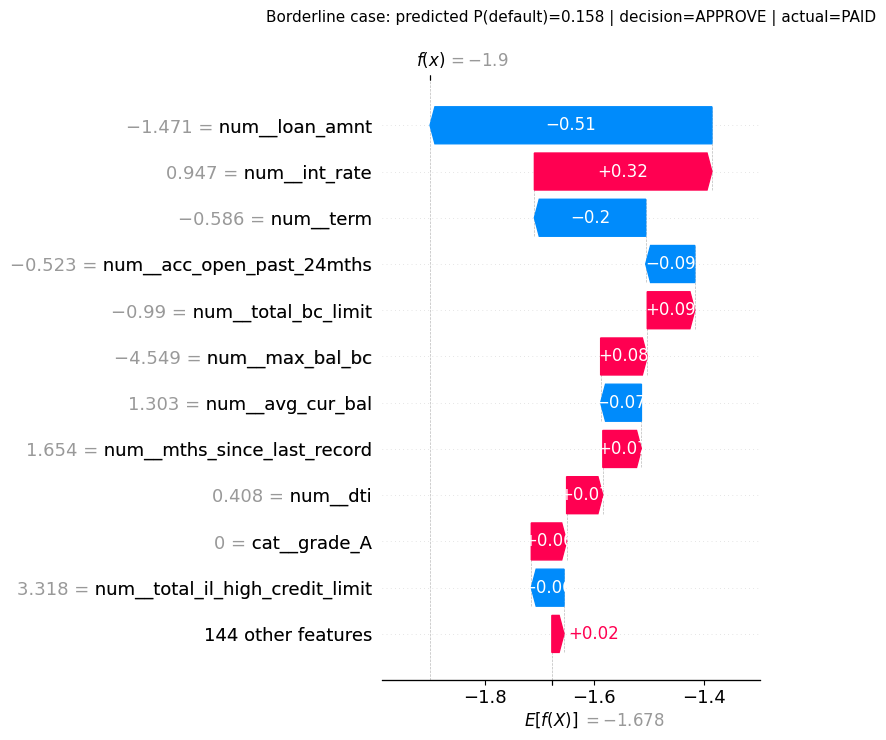

In [9]:
#  SHAP for the three specific borrowers
selected_indices = [idx for _, idx in selected]
x_selected = x_val_proc[selected_indices]
shap_values_selected = explainer.shap_values(x_selected)

# Handle SHAP format
if isinstance(shap_values_selected, list):
    shap_values_selected = shap_values_selected[1]

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else float(np.atleast_1d(expected_value)[0])

# separate figures
for i, (label, idx) in enumerate(selected):
    fig = plt.figure(figsize=(12, 7))
    
    expl = shap.Explanation(
        values = shap_values_selected[i],
        base_values = expected_value,
        data= x_val_proc[idx],
        feature_names = list(feature_names)
    )
    
    shap.plots.waterfall(expl, max_display=12, show=False)
    
    actual = 'DEFAULTED' if y_val[idx] else 'PAID'
    decision = 'REJECT' if val_probs_all[idx] >= best_threshold else 'APPROVE'
    plt.title(
        f'{label}: predicted P(default)={val_probs_all[idx]:.3f} | '
        f'decision={decision} | actual={actual}',
        fontsize = 11, pad = 20
    )
    plt.tight_layout()
    
    fname = label.lower().replace(' ', '_').replace('-', '_')
    plt.savefig(f"../reports/figures/shap_waterfall_{fname}.png", dpi=120, bbox_inches='tight')
    plt.show()